### [ 주제 : 평가 - AUC와 판정 임계값 ]
- **[0] 준비** : 03과 동일한 데이터 재구성 + 저장된 모델 로드
- **[1] 복원 오차** : 테스트 전체(정상 214 + 이상 356)의 오차 계산
- **[2] 분포 확인** : 히스토그램으로 두 그룹이 벌어졌는지 눈으로
- **[3] AUC** : 벌어진 정도를 점수로 (1.0 = 완벽, 0.5 = 동전던지기)
- **[4] 임계값 + 혼동행렬** : 실제 판정 규칙 만들기

> **완료 기준** : ① 히스토그램에서 두 분포가 갈라져 보임 ② AUC 계산됨 ③ 임계값 기준 TP/FP/FN 집계

**📍 전체 코드 흐름 지도**

```
ae_id00_v1.pth ──▶ model (클래스 정의 후 load_state_dict로 가중치 채움)

test_normalNP (214,64,313) ──┐
test_abnormalNP (356,64,313)─┤  recon_errors(model, 배열)
trainNP (854,64,313) ────────┘        │  .mean(dim=1) = 샘플별 오차
                                      ▼
     err_train (854,)   err_normal (214,)   err_abnormal (356,)
          │                  └────────┬────────┘
          │                           ▼
          │              히스토그램 + AUC (얼마나 벌어졌나)
          ▼
   THRESHOLD = 90퍼센타일 ──▶ 판정: 오차 > THRESHOLD → 이상
                                      ▼
                          혼동행렬 (TP/FP/TN/FN 집계)
```

**[0] 준비**

03과 **완전히 동일한** 로드/분리/정규화를 재실행한다 (seed 42 → 같은 분리 재현).
다르게 하면 모델이 학습 때 본 데이터가 테스트에 섞여 평가가 오염된다.

In [1]:
## 모듈 로딩
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, roc_curve

In [4]:
## => 설정 (03과 동일해야 함)
SAVE_DIR = '../data/processed/slider'
MODEL_DIR = '../models'
TRAIN_RATIO = 0.8
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [10]:
## => 03과 완전히 동일한 로드/분리/정규화 (03 노트북의 Part A 두 셀을 그대로)
normalNP = np.load(f'{SAVE_DIR}/id_00_normal.npy')
abnormalNP = np.load(f'{SAVE_DIR}/id_00_abnormal.npy')

np.random.seed(42)
idx = np.random.permutation(len(normalNP))
TRAIN_NUM = int(len(normalNP) * TRAIN_RATIO)

trainNP = normalNP[idx[:TRAIN_NUM]]
test_normalNP = normalNP[idx[TRAIN_NUM:]]

MIN = trainNP.min()
MAX = trainNP.max()
trainNP = (trainNP - MIN) / (MAX - MIN)
test_normalNP = (test_normalNP -MIN) / (MAX-MIN)
test_abnormalNP = (abnormalNP -MIN) / (MAX - MIN)

print(f'{trainNP.shape}, {test_normalNP.shape}. {abnormalNP.shape}')

(854, 64, 313), (214, 64, 313). (356, 64, 313)


In [8]:
## => 모델 클래스 정의(03과 동일하게 복사) + 저장된 가중치 로드
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(20032, 512), nn.ReLU(),
            nn.Linear(512, 64),    nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 512),    nn.ReLU(),
            nn.Linear(512, 20032), nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))
    
model = AutoEncoder()
model.load_state_dict(torch.load(f'{MODEL_DIR}/ae_id00_v1.pth', weights_only=True))
model = model.to(DEVICE)
print('모델 로드 완료')


모델 로드 완료


**[1] 복원 오차 계산**

03에서 1개씩 하던 복원 실험을 **한 번에 전체**로.
핵심은 `.mean(dim=1)` — dim=1은 "행(샘플)별 평균"이라 샘플마다 오차 숫자 1개씩 나온다.
(03의 `.mean()`은 전체 평균 1개였음)

In [13]:
## -> 함수 기능 : 배열 전체의 샘플별 복원 오차 계산
## -> 함수 이름 : recon_errors
## -> 매개 변수 : model, dataNP - (개수, 64, 313) 배열
## -> 함수 결과 : (개수,) 크기 오차 배열
def recon_errors(model,dataNP):
    model.eval()
    with torch.no_grad():
        x = torch.FloatTensor(dataNP.reshape(len(dataNP),-1)).to(DEVICE)
        out = model(x)
        err = ((x-out)**2).mean(dim=1)
    return err.cpu().numpy()

err_train = recon_errors(model,trainNP)
err_normal = recon_errors(model,test_normalNP)
err_abnormal = recon_errors(model,test_abnormalNP)

print(f'정상 오차 평균 : {err_normal.mean():.6f}')
print(f'이상 오차 평균 : {err_abnormal.mean():.6f}') 



정상 오차 평균 : 0.001511
이상 오차 평균 : 0.003484


**[2] 오차 분포 히스토그램**

"이상 오차 > 정상 오차"를 570개 전체로 확인하는 그림.
파란 덩어리(정상)와 주황 덩어리(이상)가 벌어져 있을수록 좋은 모델.

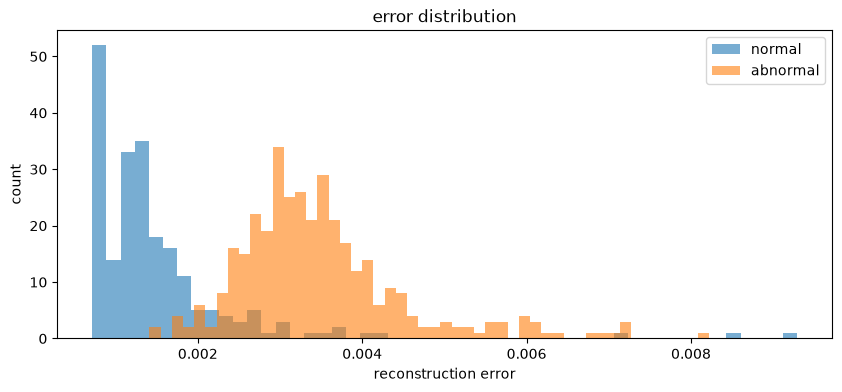

In [14]:
## => 두 오차 분포 겹쳐 그리기
plt.figure(figsize=(10, 4))
plt.hist(err_normal,   bins=50, alpha=0.6, label='정상')
plt.hist(err_abnormal, bins=50, alpha=0.6, label='이상')
plt.xlabel('복원 오차')
plt.ylabel('개수')
plt.legend()
plt.title('정상·이상 복원 오차 분포')
plt.show()

**[3] AUC 계산**

"벌어진 정도"를 점수 하나로: 1.0 = 완벽 분리, 0.5 = 동전던지기.
정답표(y_true)와 점수(y_score = 오차)만 주면 sklearn이 계산해준다.

In [ ]:
## => 정답 라벨과 점수 만들어 AUC 계산
y_true = np.array([0] * len(err_normal) + [1] * len(err_abnormal))
y_score = np.concatenate([err_normal, err_abnormal])

auc = roc_auc_score(y_true, y_score)
print(f'AUC : {auc:.4f}')

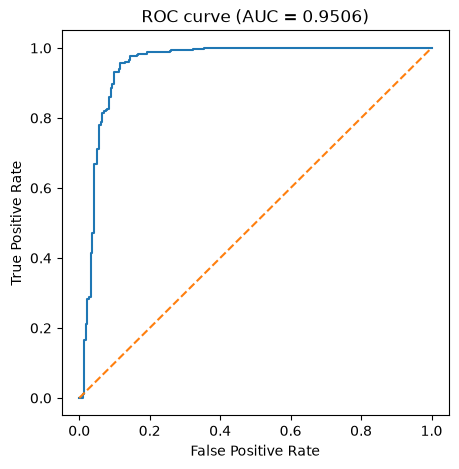

In [16]:
## => (선택) ROC 곡선 : 임계값을 움직여가며 (오탐률, 감지율) 궤적 그리기
fpr,tpr,_ = roc_curve(y_true,y_score)
plt.figure(figsize=(5,5))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel('거짓 양성률 (FPR)')
plt.ylabel('진짜 양성률 (TPR)')
plt.title(f'ROC 곡선 (AUC = {auc:.4f})')
plt.show()

**[4] 임계값 + 혼동행렬**

임계값은 **학습에 쓴 정상 오차**에서 정한다 (테스트로 정하면 반칙 — 실전엔 이상 데이터가 없다).
90퍼센타일 = "정상이라면 100번 중 90번은 이 오차 안쪽". 공장은 미탐 비용이 커서 민감하게(낮게) 잡음.

In [35]:
## => 임계값 : 학습 정상 오차의 99퍼센타일
THRESHOLD = np.percentile(err_train,90)
print(f'임계값 : {THRESHOLD:.6f}')
pred = (y_score > THRESHOLD).astype(int)


임계값 : 0.001989


In [36]:
## => 혼동행렬 : 4가지 경우 개수 세기 (for문으로 직접)
tp,fp,tn,fn = 0,0,0,0
for i in range(len(y_true)):
    if y_true[i] == 1 and pred[i] == 1: tp = tp + 1
    
    if y_true[i] == 0 and pred[i] == 1: fp = fp + 1
    
    if y_true[i] == 0 and pred[i] == 0: tn = tn + 1
    
    if y_true[i] == 1 and pred[i] == 0: fn = fn + 1

print(f'이상 감지 성공(TP) : {tp} / {tp+fn}')
print(f'오탐(FP)           : {fp} / {fp+tn}')
print(f'미탐(FN)           : {fn}')

이상 감지 성공(TP) : 348 / 356
오탐(FP)           : 31 / 214
미탐(FN)           : 8


## 결과 기록

| 항목 | 값 |
|------|----|
| AUC | 0.9506 |
| 임계값 (학습 정상 오차 90퍼센타일) | 0.001989 |
| 이상 감지 성공 TP | 348 / 356 |
| 오탐 FP | 31 / 214 |
| 미탐 FN | 8 |

**해석** : AUC 0.95로 정상/이상 분리력은 우수. 90퍼센타일 임계값에서 이상 356건 중 348건 감지(미탐 8건),
오탐 31건. 공장에선 미탐 비용이 크므로, 오탐을 감수하고 임계값을 민감하게(90퍼센타일) 잡은 지점이다.

## 다음 단계

- 결과 기록까지 채우면 4단계(평가) 완료 → `docs/면접_예상질문.md`의 🔜 항목도 실제 수치로 채우기
- 다음은 05번 : 0dB / -6dB 데이터로 같은 파이프라인 반복 → 소음 강도별 AUC 비교
